# 🎬 Netflix Exploratory Data Analysis (EDA)

This notebook performs a complete exploratory data analysis on the Netflix dataset
using reusable cleaning and plotting functions.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [2]:
df=pd.read_csv('netflix1.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.shape

(8807, 12)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


### Observation
- Dataset contains both categorical and numerical columns
- Several columns have missing(NaN) values

## Drop Text Columns

In [6]:
df.drop(columns=['title','cast','director','description'], inplace=True)

## Observation
Text heavy columns were removed as they were not required for numerical/categorical EDA

In [7]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

## Observation
duration column contains both numbers and text data, so that numeric values are extracted

### Overview Of Data

In [8]:
def dataset_overview(df):
    print("🔹 Shape:", df.shape)
    print("\n🔹 Info:")
    display(df.info())
    print("\n🔹 Missing Values:")
    display(df.isnull().sum())
    print("\n🔹 Duplicates:", df.duplicated().sum())
    
dataset_overview(df)

🔹 Shape: (8807, 9)

🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   show_id       8807 non-null   object 
 1   type          8807 non-null   object 
 2   country       7976 non-null   object 
 3   date_added    8797 non-null   object 
 4   release_year  8807 non-null   int64  
 5   rating        8803 non-null   object 
 6   duration      8804 non-null   object 
 7   listed_in     8807 non-null   object 
 8   duration_num  8804 non-null   float64
dtypes: float64(1), int64(1), object(7)
memory usage: 619.4+ KB


None


🔹 Missing Values:


show_id           0
type              0
country         831
date_added       10
release_year      0
rating            4
duration          3
listed_in         0
duration_num      3
dtype: int64


🔹 Duplicates: 0


### Dropping Duplicates

In [9]:
def drop_duplicates(df):
    return df.drop_duplicates()
drop_duplicates(df)

,show_id,type,country,date_added,release_year,rating,duration,listed_in,duration_num
0,s1,Movie,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,90.0
1,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2.0
2,s3,TV Show,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1.0
3,s4,TV Show,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV",1.0
4,s5,TV Show,India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",2.0
...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers",158.0
8803,s8804,TV Show,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies",2.0
8804,s8805,Movie,United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",88.0
8805,s8806,Movie,United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies",88.0


### Handling Missing Values

In [10]:
def handle_missing(df):
    for col in df.columns:
        if df[col].dtype in ['int64','float64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    return df

handle_missing(df)

C:\Users\mishr\AppData\Local\Temp\ipykernel_2528\2730722994.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\mishr\AppData\Local\Temp\ipykernel_2528\2730722994.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

,show_id,type,country,date_added,release_year,rating,duration,listed_in,duration_num
0,s1,Movie,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,90.0
1,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2.0
2,s3,TV Show,United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1.0
3,s4,TV Show,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV",1.0
4,s5,TV Show,India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",2.0
...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers",158.0
8803,s8804,TV Show,United States,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies",2.0
8804,s8805,Movie,United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",88.0
8805,s8806,Movie,United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies",88.0


### Handling Outliers

In [11]:
def handle_outliers(df, num_cols):
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5*IQR
        upper = Q3 + 1.5*IQR
        df[col] = df[col].clip(lower, upper)
    return df

num_cols=['release_year','duration_num']
handle_outliers(df, num_cols)

,show_id,type,country,date_added,release_year,rating,duration,listed_in,duration_num
0,s1,Movie,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,90.0
1,s2,TV Show,South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2.0
2,s3,TV Show,United States,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",1.0
3,s4,TV Show,United States,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV",1.0
4,s5,TV Show,India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",2.0
...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers",158.0
8803,s8804,TV Show,United States,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies",2.0
8804,s8805,Movie,United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",88.0
8805,s8806,Movie,United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies",88.0


#### Observation 
Text heavy columns were removed because they were not required for numerical/categorical EDA.

In [ ]:
df['duration_num'] = df['duration'].str.extract('(\d+)').astype(float)

#### Observation
There are both numbers and text values in duration columns, so numeric values gets extracted.

### Numerical Column Plots

In [12]:
df.select_dtypes(include=['int64', 'float64']).columns

Index(['release_year', 'duration_num'], dtype='object')

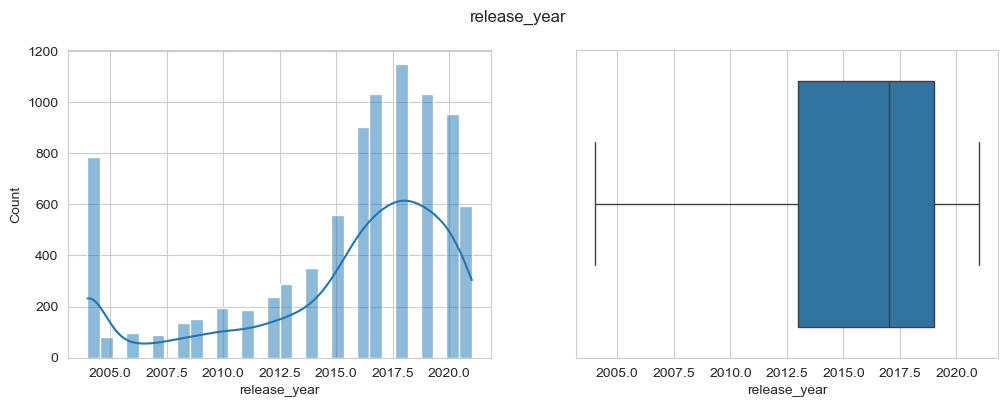

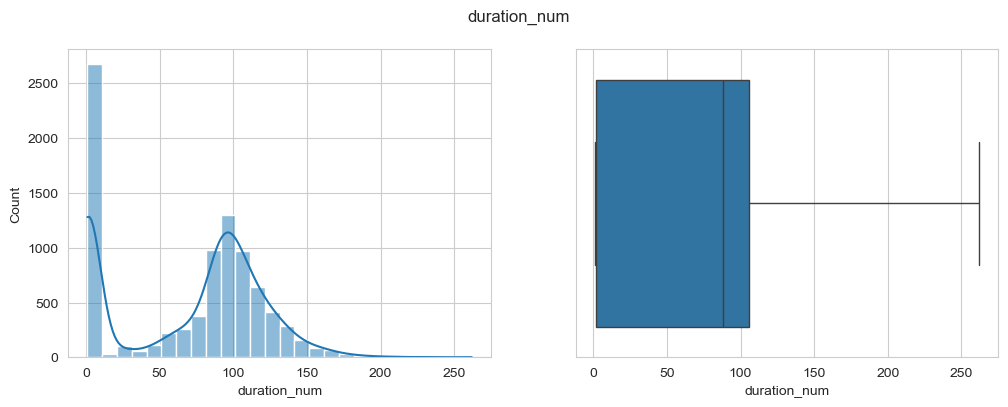

In [13]:
def plot_numerical(df, num_cols):
    for col in num_cols:
        fig, ax = plt.subplots(1, 2, figsize=(12,4))
        sns.histplot(df[col], kde=True, ax=ax[0])
        sns.boxplot(x=df[col], ax=ax[1])
        fig.suptitle(col)
        plt.show()

num_cols=['release_year', 'duration_num']
plot_numerical(df, num_cols)

In [14]:
np.mean(df['duration_num'])

np.float64(69.84614511184286)

## Observation
1. From 2015 onwards, the number of movies and TV shows released on Netflix increased significantly.
2. The year 2018 recorded the highest number of releases, indicating a peak in content addition.
3. Most movies and TV shows have a duration between 70 and 90 minutes, showing that Netflix content is generally produced with standard feature-length  formats.
4. Note: Duration represents minutes for movies and seasons for TV shows, so interpretation may occur across content types

### Categorical Column Plots

In [15]:
df.select_dtypes(include=['object']).columns

Index(['show_id', 'type', 'country', 'date_added', 'rating', 'duration',
       'listed_in'],
      dtype='object')

In [16]:
df.drop(columns=['show_id','date_added','duration'],inplace=True)

In [17]:
top_countries = df['country'].value_counts().head(10).index
df['country'] = df['country'].where(df['country'].isin(top_countries), 'Other')

In [18]:
top_genres = df['listed_in'].value_counts().head(10).index
df['listed_in'] = df['listed_in'].where(df['listed_in'].isin(top_genres), 'Other')

### Observation
#### Categorical Feature Selection
- Identifier and date-based columns were excluded from categorical analysis
- Only business-relevant categorical features were used for visualization

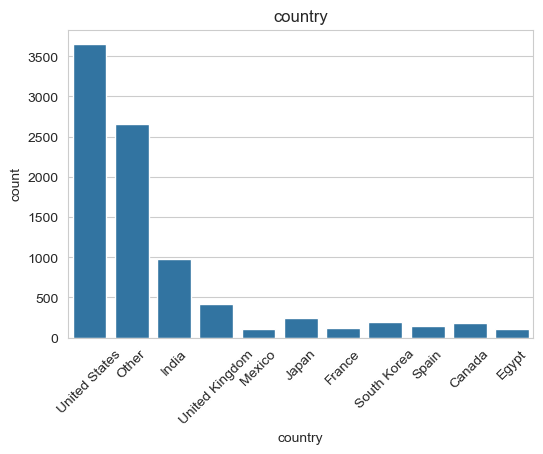

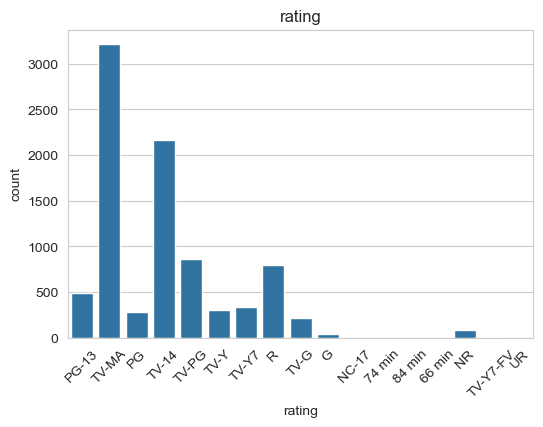

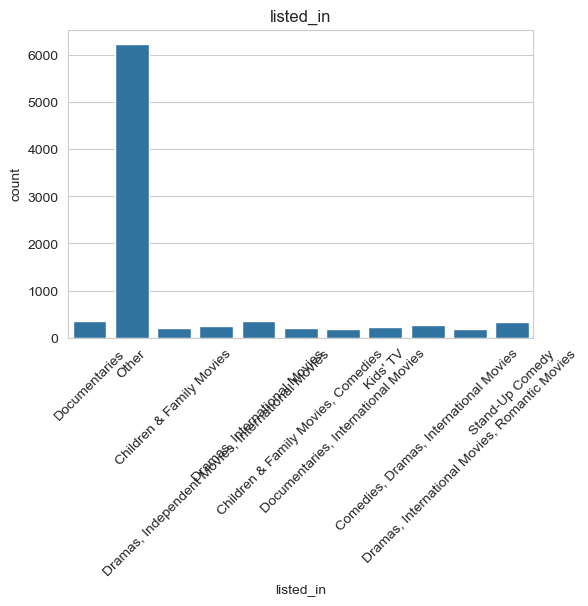

In [19]:
def plot_categorical(df, cat_cols):
    for col in cat_cols:
        plt.figure(figsize=(6,4))
        sns.countplot(x=df[col])
        plt.title(col)
        plt.xticks(rotation=45)
        plt.show()

cat_cols=['country', 'rating','listed_in']
plot_categorical(df, cat_cols)

## Observation
1. Production of Movies is approximately twice of TV shows which shows that viewers like movies more over TV shows
2. USA has the highest number of releases followed by India
3. TV-MA is the most common rating on Netflix which shows that Netflix content is targeted Mature and teenage audience more than Family friendly
4. Drama related genres dominate Netflix library with International Movies and Comedies while Kids and family movies has small proportion of catalog

## Target vs Feature

In [20]:
df['is_movie'] = (df['type'] == 'Movie').astype(int)

### Observation 
We have to make is_movie numerical column as it is required to represent target
- 1 → Movie
- 0 → TV Show

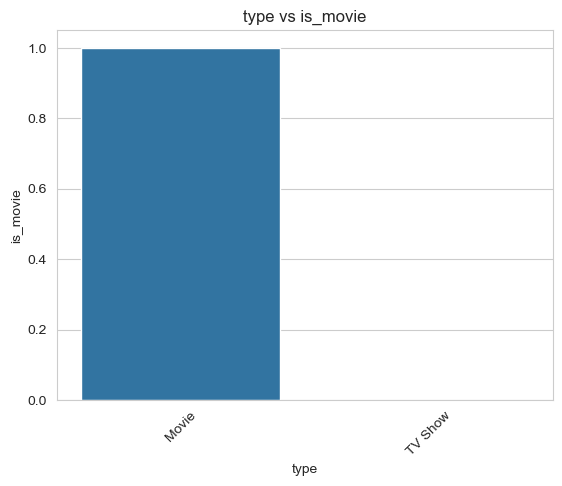

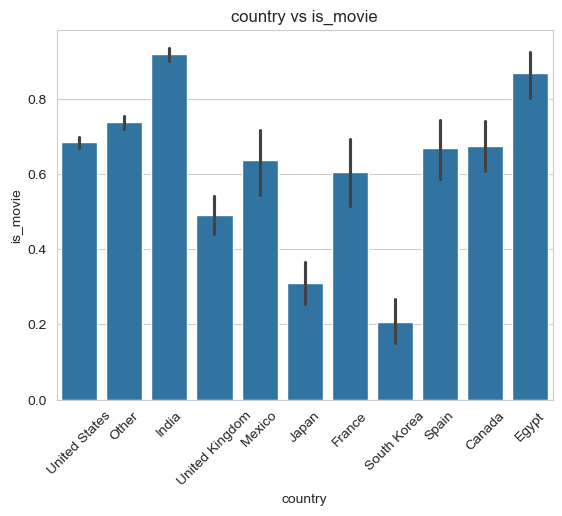

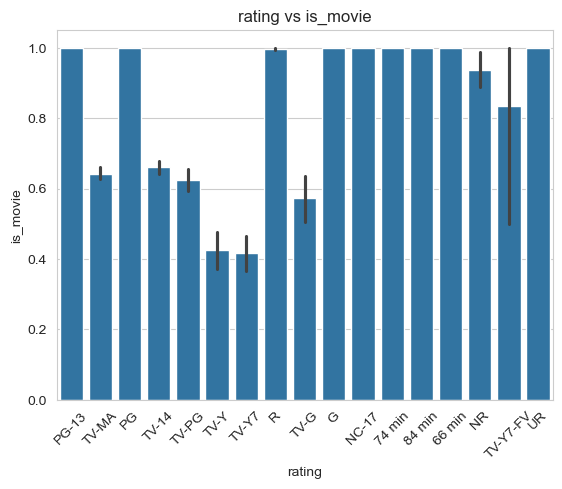

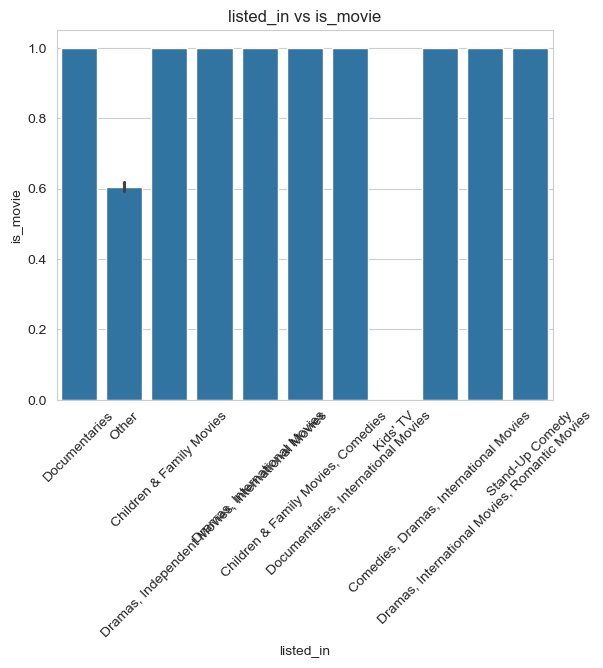

In [21]:
def plot_cat_vs_target(df, cat_cols, target):
    for col in cat_cols:
        sns.barplot(x=col, y=target, data=df)
        plt.title(f"{col} vs {target}")
        plt.xticks(rotation=45)
        plt.show()

cat_cols = ['type', 'country', 'rating','listed_in']
plot_cat_vs_target(df, cat_cols,'is_movie')

## 📊 Interpretation for EACH column

### type vs is_movie
- This plot is trivial and redundant, because is_movie was created FROM type which is not useful for EDA

### country vs is_movie
- About 90% of Netflix titles from India are movies followed by USA(75%), which doesn't mean India has highest count of Movies
- Japan and South Korea has least rate of movies means thet have more rate of TV shows

### rating vs is_movie
- Most of the category has approx 100% rating for movies while TV-Y and TV-Y7 has rating below 45% 

### listed_in vs is_movie
- This pattern reflects Netflix’s genre-specific content strategy, where storytelling
genres favor movies while family and episodic content favor TV shows.

# Full EDA Pipeline

🔹 Shape: (8807, 7)

🔹 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   type          8807 non-null   object 
 1   country       8807 non-null   object 
 2   release_year  8807 non-null   int64  
 3   rating        8807 non-null   object 
 4   listed_in     8807 non-null   object 
 5   duration_num  8807 non-null   float64
 6   is_movie      8807 non-null   int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 481.8+ KB


None


🔹 Missing Values:


type            0
country         0
release_year    0
rating          0
listed_in       0
duration_num    0
is_movie        0
dtype: int64


🔹 Duplicates: 2601


C:\Users\mishr\AppData\Local\Temp\ipykernel_2528\2730722994.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\mishr\AppData\Local\Temp\ipykernel_2528\2730722994.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\mishr\AppData\Lo

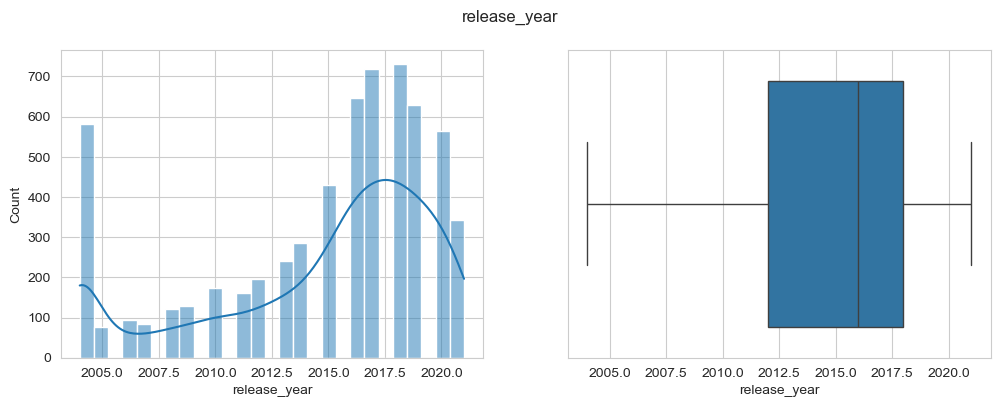

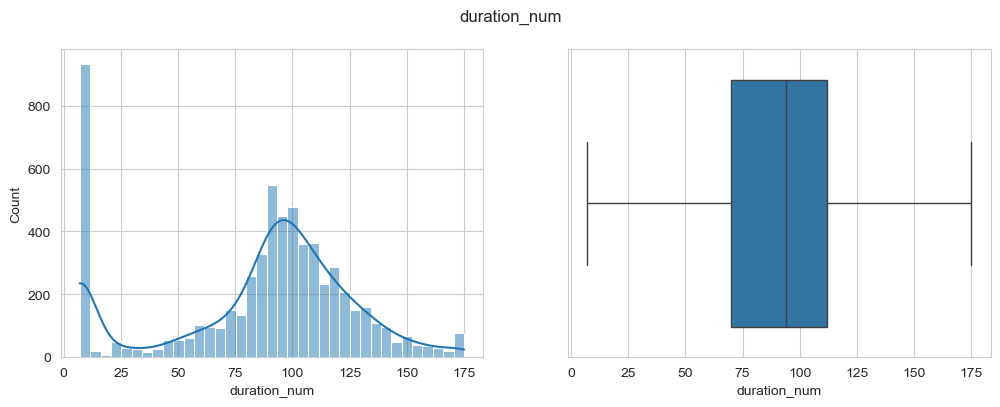

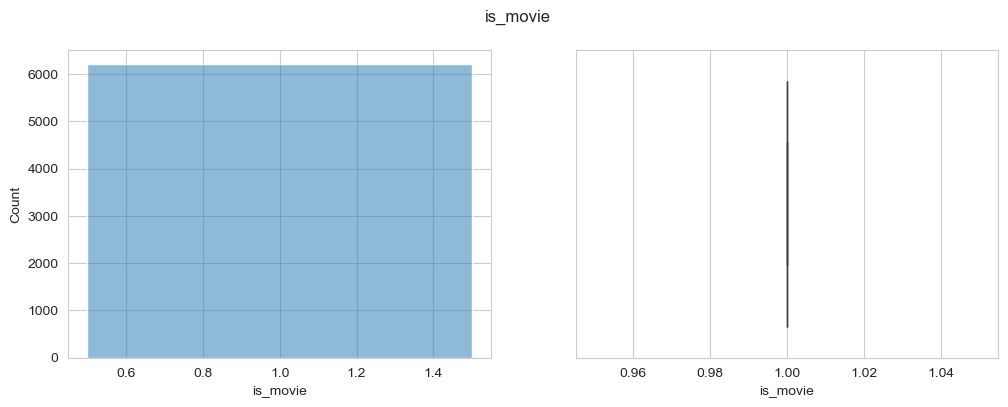

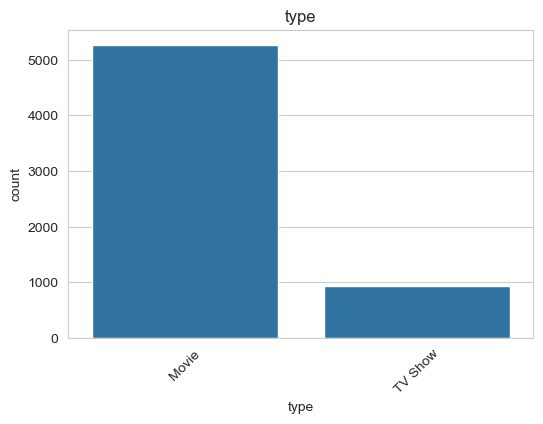

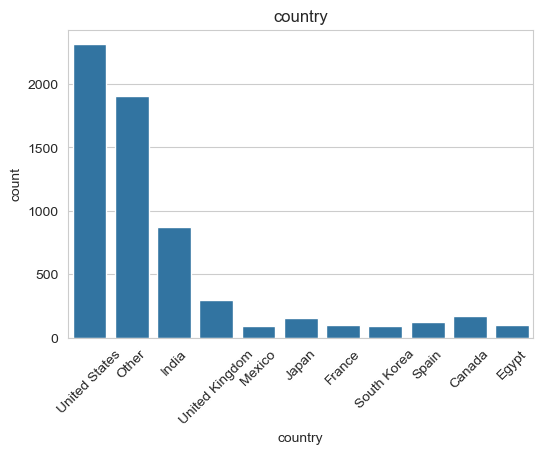

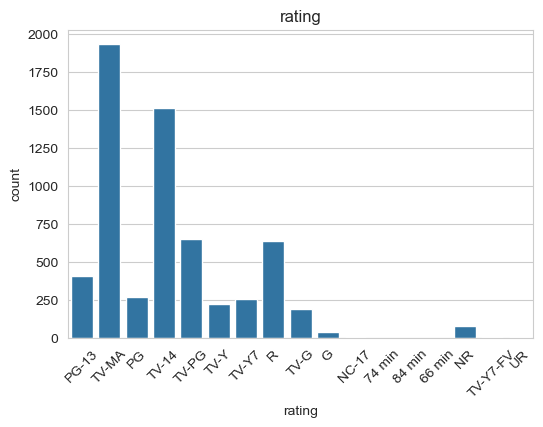

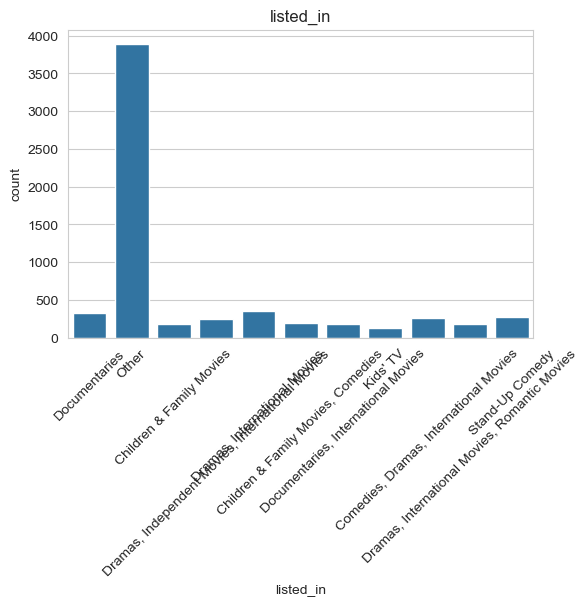

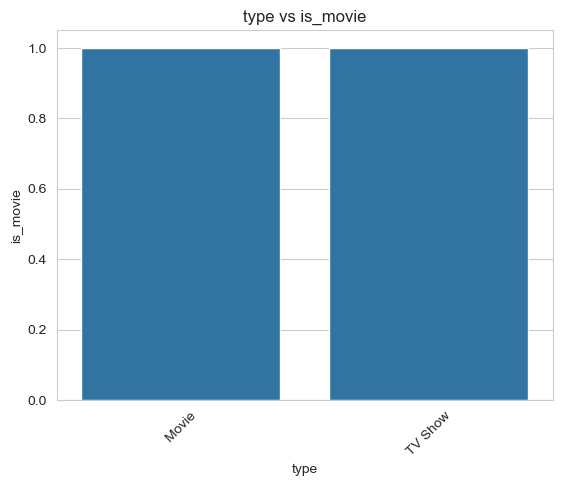

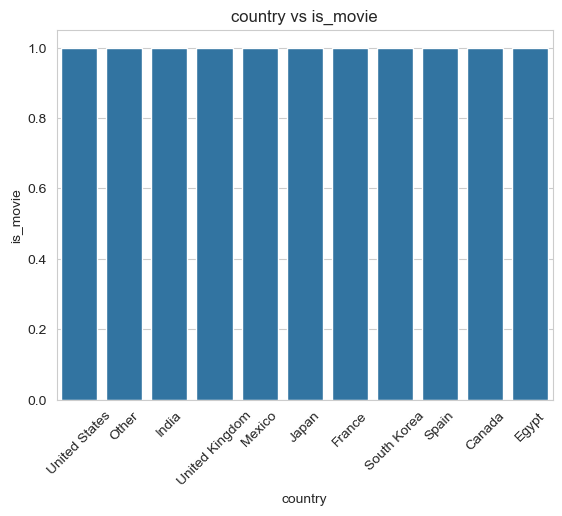

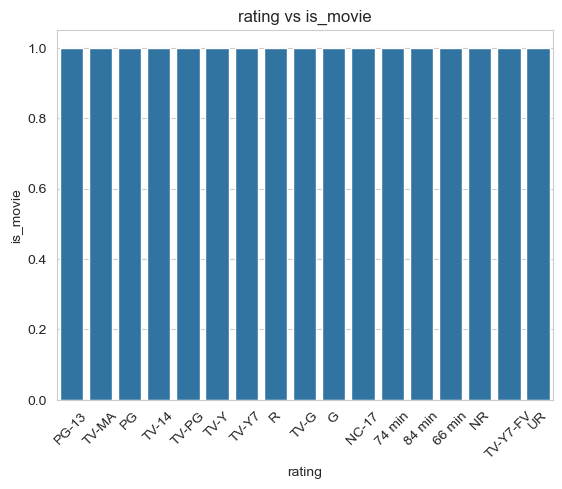

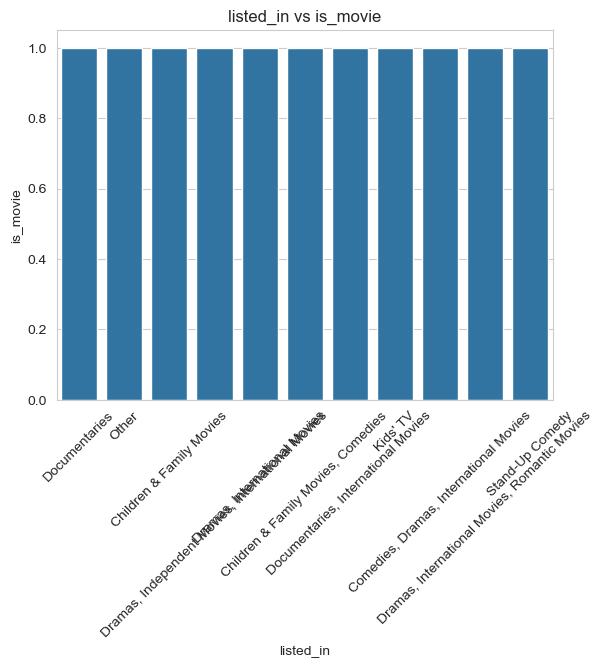

In [22]:
def full_eda_pipeline(df, target=None):
    num_cols = df.select_dtypes(include=['int64','float64']).columns
    cat_cols = df.select_dtypes(include='object').columns

    dataset_overview(df)

    df = drop_duplicates(df)
    df = handle_missing(df)
    df = handle_outliers(df, num_cols)

    plot_numerical(df, num_cols)
    plot_categorical(df, cat_cols)

    if target:
        plot_cat_vs_target(df, cat_cols, target)
    return df

df = full_eda_pipeline(df, target='is_movie')

# Observation
- Netflix content releases increased significantly after 2015, with 2018 being the peak year.

- Movies dominate the platform compared to TV shows, indicating a movie-focused content strategy.

- Most titles follow standard feature-length durations, reflecting typical industry norms.

- Ratings such as TV-MA, TV-14, and PG-13 are the most common, showing a focus on mature and teenage audiences.

- Drama and international genres are largely movie-oriented, while kids and TV-related genres favor episodic formats.

- Country-level analysis shows that India has a high proportion of movie releases, highlighting regional content preferences.

# Conclusion

This project presents a structured exploratory data analysis of the Netflix dataset
using reusable cleaning and visualization functions. The analysis highlights Netflix’s
strong growth after 2015, dominance of movies over TV shows, and a clear focus on
mature and teenage audiences. Genre and country-level insights reveal region-specific
and genre-specific content strategies. Overall, this EDA demonstrates the importance
of understanding data patterns and quality before moving toward any modeling or
business decisions.
